In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/adeleon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/adeleon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
with open("PythonEssays.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [4]:
sentences = sent_tokenize(text)
sentences = [s.strip().lower().replace(",", "") for s in sentences]
df = pd.DataFrame(sentences, columns=["sentence"])
df["tokens"] = df["sentence"].apply(word_tokenize)

In [5]:
df

,sentence,tokens
0,﻿during a spring break my family and i went to...,"[﻿during, a, spring, break, my, family, and, i..."
1,it had been a year since i last swam and i des...,"[it, had, been, a, year, since, i, last, swam,..."
2,at that time i didn't even consider how much t...,"[at, that, time, i, did, n't, even, consider, ..."
3,entering the pool room the nostalgic smell of ...,"[entering, the, pool, room, the, nostalgic, sm..."
4,as we went around the pool to a seat the littl...,"[as, we, went, around, the, pool, to, a, seat,..."
...,...,...
915,this proves how the scientific revolution revo...,"[this, proves, how, the, scientific, revolutio..."
916,since these discoveries were made it allowed f...,"[since, these, discoveries, were, made, it, al..."
917,for example the fact that we have rocketships ...,"[for, example, the, fact, that, we, have, rock..."
918,if the scientists during the scientific revolu...,"[if, the, scientists, during, the, scientific,..."


In [6]:
cleaned_sentences = []

for sentence in df["sentence"]:
    words = sentence.split()

    filtered_words = []

    for word in words:
        if word.lower() not in ENGLISH_STOP_WORDS:
            filtered_words.append(word)

    cleaned_sentence = " ".join(filtered_words)
    cleaned_sentences.append(cleaned_sentence)

df["sentence"] = cleaned_sentences
df["tokens"] = df["tokens"].apply(lambda tokens: [t for t in tokens if t not in ENGLISH_STOP_WORDS])

In [7]:
df['sentence']

0      ﻿during spring break family went resort idea g...
1      year swam desired soft touch water shifts make...
2      time didn't consider time i'd spend taking car...
3      entering pool room nostalgic smell chlorine im...
4       went pool seat little ones jumping anticipation.
                             ...                        
915    proves scientific revolution revolutionized ch...
916    discoveries allowed observations universe know...
917    example fact rocketships able calculate trajec...
918    scientists scientific revolution failed prove ...
919    discoveries extremely important progress human...
Name: sentence, Length: 920, dtype: object

In [8]:
df

,sentence,tokens
0,﻿during spring break family went resort idea g...,"[﻿during, spring, break, family, went, resort,..."
1,year swam desired soft touch water shifts make...,"[year, swam, desired, soft, touch, water, shif..."
2,time didn't consider time i'd spend taking car...,"[time, did, n't, consider, time, 'd, spend, ta..."
3,entering pool room nostalgic smell chlorine im...,"[entering, pool, room, nostalgic, smell, chlor..."
4,went pool seat little ones jumping anticipation.,"[went, pool, seat, little, ones, jumping, anti..."
...,...,...
915,proves scientific revolution revolutionized ch...,"[proves, scientific, revolution, revolutionize..."
916,discoveries allowed observations universe know...,"[discoveries, allowed, observations, universe,..."
917,example fact rocketships able calculate trajec...,"[example, fact, rocketships, able, calculate, ..."
918,scientists scientific revolution failed prove ...,"[scientists, scientific, revolution, failed, p..."


In [9]:
documents = []
for i in range(0, len(df), 10):
    chunk = df["sentence"][i:i+10].tolist()
    documents.append(" ".join(chunk))


In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(documents)
doc_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [11]:
doc_df

,10,100,11,118,12,120,1200,123,13,133,...,yet,york,you,young,younger,yourself,zero,zeus,zodiac,zodiacs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,4,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
88,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
89,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
90,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
word_counts = doc_df.sum(axis=0).sort_values(ascending=False)
word_counts.columns = ["word", "count"]
print(word_counts.head(10))


like        122
people      116
shows        59
macbeth      52
it           48
narrator     44
time         43
way          42
make         42
life         41
dtype: int64


In [13]:
#like being my most common word makes sense, but macbeth is honestly unexpected. Maybe since macbeth is also the name of the book,
#it appeared in some essays not entirely about the book itself when i named it?

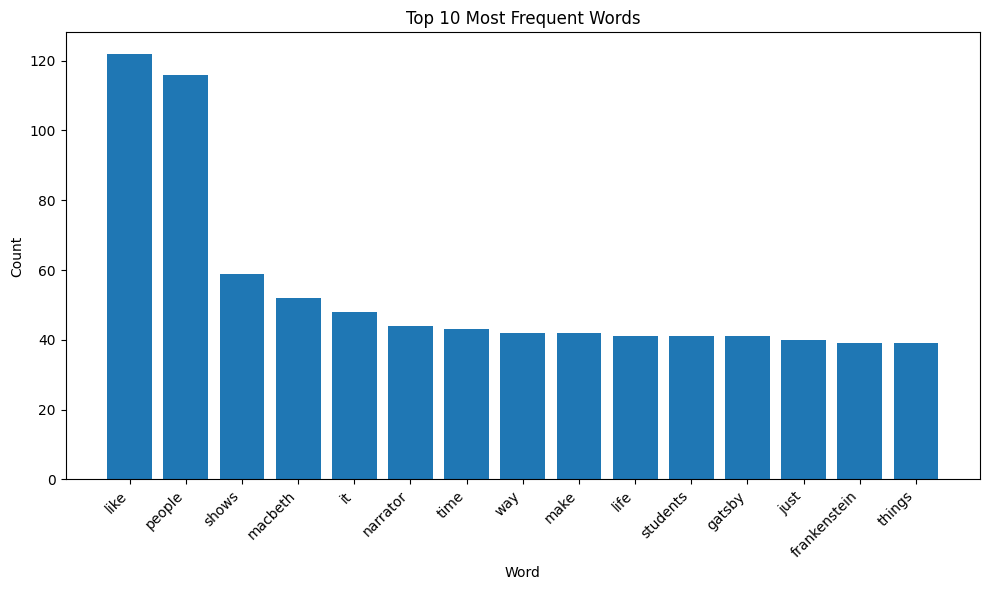

In [21]:
top_words = word_counts.head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_words.index, top_words.values)
plt.xlabel("Word")
plt.ylabel("Count")
plt.title("Top 10 Most Frequent Words")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(documents)

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

In [23]:
tfidf_df

,10,100,11,118,12,120,1200,123,13,133,...,yet,york,you,young,younger,yourself,zero,zeus,zodiac,zodiacs
0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.237226,0.0,0.0,0.0,0.000000,0.000000
1,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.064610,0.0,0.0,0.0,0.000000,0.000000
2,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
3,0.088164,0.0,0.0,0.0,0.000000,0.0,0.108755,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
4,0.000000,0.0,0.0,0.0,0.099932,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
88,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000
89,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.224365,0.112183
90,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000


In [26]:
tfidf_scores = tfidf_df.sum(axis=0).sort_values(ascending=False)
print(tfidf_scores.head(10))

people          3.407830
like            3.384902
macbeth         2.943433
sonny           2.636309
narrator        2.443736
gatsby          2.421215
tom             2.152578
students        2.125710
frankenstein    2.122596
shows           2.086777
dtype: float64


In [ ]:
#TF-IDF is different because it penalizes those common words like 'like' seen across multiple documents. Because of this,
#words that are said frequently in one document but don't appear in every document get the highest score, showing that 'people' and 'like'
#appear the most in a document while not appearing in every document.

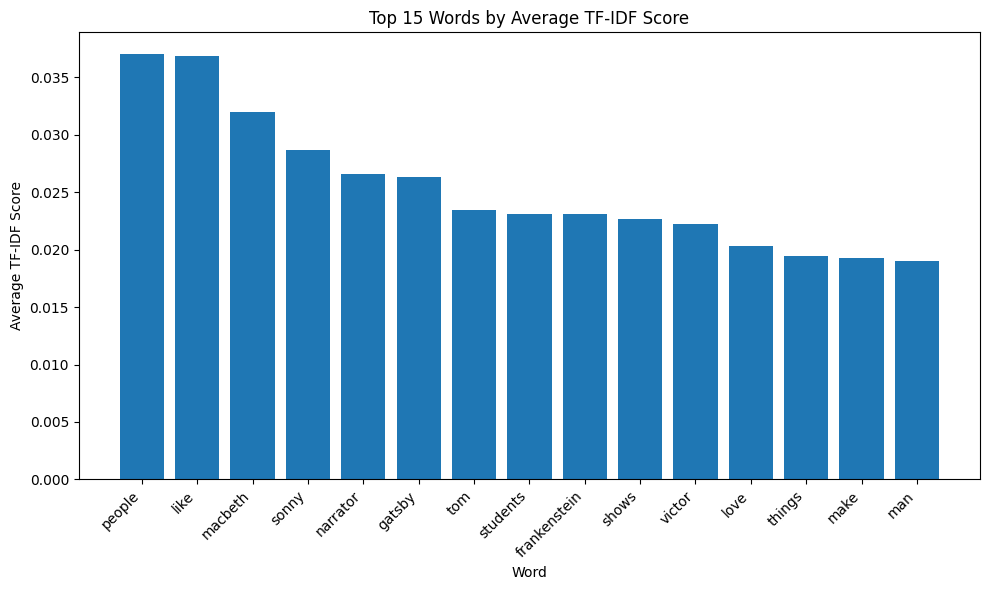

In [25]:
tfidf_avg = tfidf_df.mean(axis=0).sort_values(ascending=False)

top_tfidf = tfidf_avg.head(15)

plt.figure(figsize=(10, 6))
plt.bar(top_tfidf.index, top_tfidf.values)
plt.xlabel("Word")
plt.ylabel("Average TF-IDF Score")
plt.title("Top 15 Words by Average TF-IDF Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

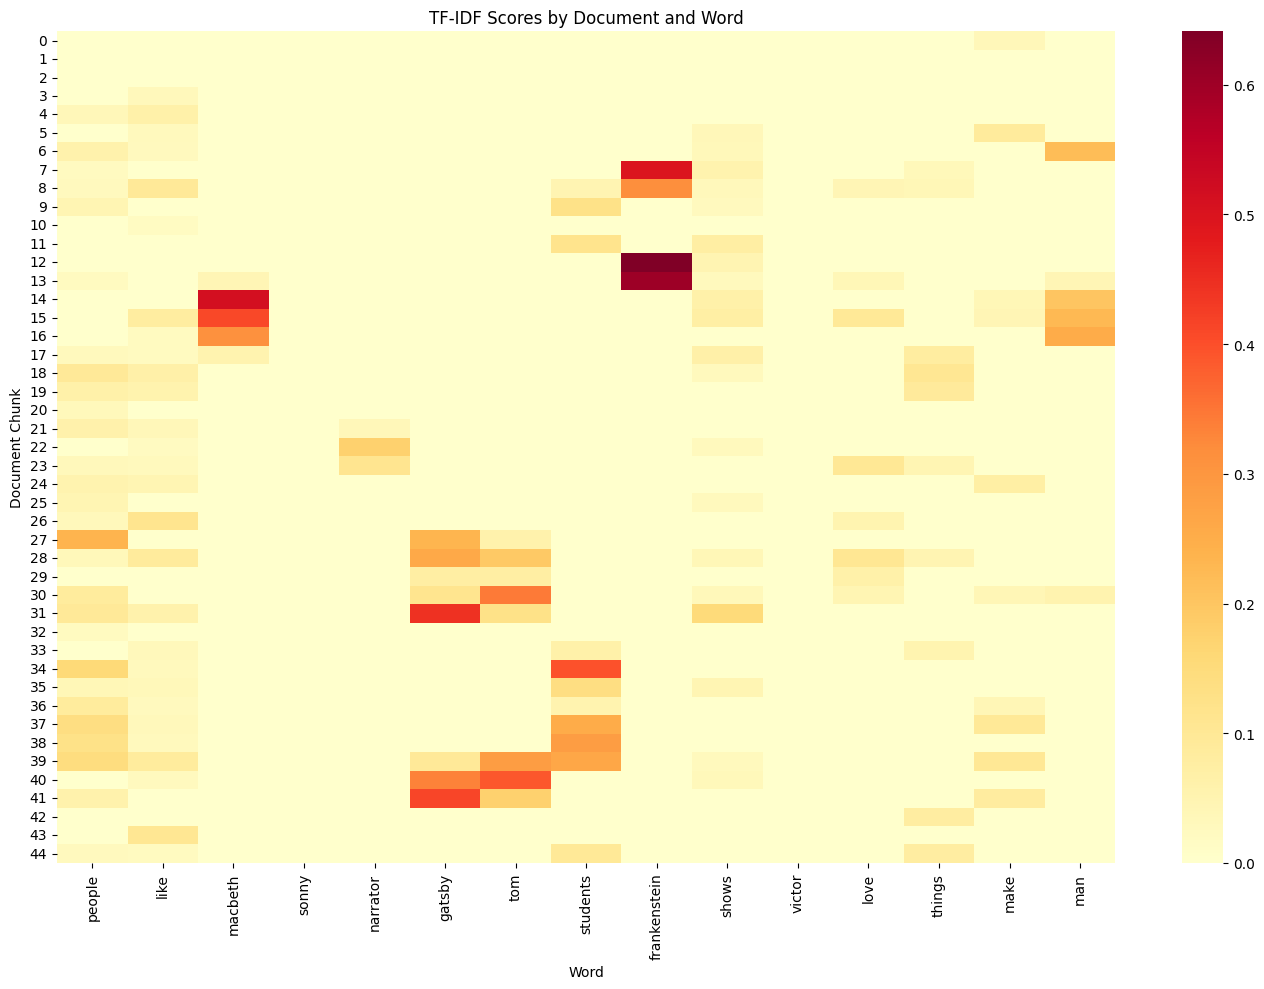

In [29]:
import seaborn as sns

top_words = tfidf_df.mean(axis=0).sort_values(ascending=False).head(15).index

heatmap_data = tfidf_df[top_words].iloc[:45]

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap="YlOrRd", xticklabels=True, yticklabels=True)
plt.title("TF-IDF Scores by Document and Word")
plt.xlabel("Word")
plt.ylabel("Document Chunk")
plt.tight_layout()
plt.show()

In [ ]:
#This chart is a heatmap showing scores in each document chunk for the first 44, showing how macbeth gets an extremely high score
#in a few, but gets no score in most.
#For personal findings, I found out that I say people and like a lot, which seems pretty unprofessional, so maybe I need to make
#my writing more professional.